In [ ]:
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict , Literal  , Union
from dotenv import load_dotenv
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel , Field
load_dotenv()


True

In [66]:
model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash-lite")


In [ ]:
class LLMstate(TypedDict):
    
    title :str
    outline  : str
    content : str
    overall_response: str




In [77]:
def create_outline(state : LLMstate) -> LLMstate:
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state


In [78]:
def create_content(state : LLMstate )-> LLMstate:
    title = state['title']
    outline = state['outline']

    # prompt 
    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state


In [79]:
def blog_overall_response(state : LLMstate) -> LLMstate:
    
    outline = state['outline']
    blog = state['content']
    
    prompt = f"based on this {outline} , the overall response of {blog}"
    
    feedback = model.invoke(prompt).content
    state['overall_response'] = feedback
    
    return state


In [80]:
graph = StateGraph(LLMstate)

# add node 
graph.add_node("create_outline" , create_outline)
graph.add_node("create_content" , create_content)
graph.add_node("blog_overall_response" , blog_overall_response)


In [81]:
graph.add_edge(START , "create_outline")
graph.add_edge("create_outline" , "create_content")
graph.add_edge("create_content" , "blog_overall_response")
graph.add_edge("blog_overall_response" , END)


workflow = graph.compile()


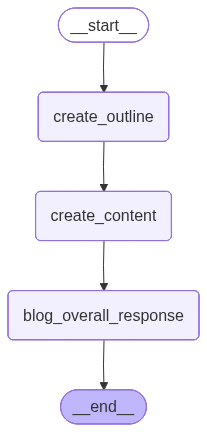

In [82]:
workflow


In [83]:
final_state = workflow.invoke({"title" : "Rise of gemini in India"})


In [87]:
final_state.keys()


dict_keys(['title', 'outline', 'content', 'overall_response'])

In [90]:
final_state.get(blog_overall_response)


In [95]:
final_state['overall_response']


'This is an excellent, comprehensive blog post outline! It covers all the essential aspects of Gemini\'s rise in India, from its technical underpinnings to its societal impact and future outlook. The structure is logical, flows well, and offers a good balance between informative content and engaging narrative.\n\nHere\'s a breakdown of what works well and a few minor suggestions for enhancement, focusing on the overall response of the blog post:\n\n## Strengths of the Blog Post Response:\n\n*   **Excellent Title Choice:** "The Gemini Ascent: How Google\'s AI is Reshaping India" is compelling, uses strong verbs, and clearly states the topic and its significance.\n*   **Strong Introduction:**\n    *   The hook effectively uses a statistic/observation about India\'s digital growth.\n    *   It clearly defines AI and its importance.\n    *   It introduces Gemini and its core strength (multimodal) early on.\n    *   The thesis statement is clear and sets a good roadmap.\n*   **Clear Explana

In [29]:
final_state


{'title': 'Rise of gemini in India',
 'outline': '## Blog Outline: The Gemini Phenomenon: Its Rise and Impact in India\n\n**Blog Title Options:**\n\n*   The Gemini Surge: How AI is Reshaping India\'s Digital Landscape\n*   Google\'s Gemini in India: A New Era of AI Innovation\n*   Beyond the Hype: Understanding Gemini\'s Real Impact in India\n*   Gemini\'s Ascent: Unlocking India\'s AI Potential\n\n**I. Introduction: Setting the Stage for Gemini\'s Arrival**\n\n*   **A. The AI Revolution is Here:**\n    *   Briefly introduce the global AI landscape and its rapid advancements.\n    *   Mention the increasing importance of AI in everyday life and business.\n*   **B. Introducing Google Gemini:**\n    *   What is Gemini? (Brief, non-technical explanation of its multi-modal capabilities and strengths).\n    *   Highlight its significance as Google\'s most advanced AI model.\n*   **C. Why India? The Perfect Ground for Growth:**\n    *   India\'s burgeoning digital economy and tech-savvy popu

In [27]:
print(final_state['outline'])


## Blog Outline: The Gemini Phenomenon: Its Rise and Impact in India

**Blog Title Options:**

*   The Gemini Surge: How AI is Reshaping India's Digital Landscape
*   Google's Gemini in India: A New Era of AI Innovation
*   Beyond the Hype: Understanding Gemini's Real Impact in India
*   Gemini's Ascent: Unlocking India's AI Potential

**I. Introduction: Setting the Stage for Gemini's Arrival**

*   **A. The AI Revolution is Here:**
    *   Briefly introduce the global AI landscape and its rapid advancements.
    *   Mention the increasing importance of AI in everyday life and business.
*   **B. Introducing Google Gemini:**
    *   What is Gemini? (Brief, non-technical explanation of its multi-modal capabilities and strengths).
    *   Highlight its significance as Google's most advanced AI model.
*   **C. Why India? The Perfect Ground for Growth:**
    *   India's burgeoning digital economy and tech-savvy population.
    *   The country's massive user base and diverse linguistic lands

In [23]:
from IPython.display import Markdown, display


In [28]:
print(final_state['content'])


## The Gemini Surge: How AI is Reshaping India's Digital Landscape

**I. Introduction: Setting the Stage for Gemini's Arrival**

The world is in the throes of an unprecedented artificial intelligence (AI) revolution. What was once the realm of science fiction is rapidly becoming an integral part of our daily lives and the engine driving global business innovation. From personalized recommendations to sophisticated medical diagnostics, AI’s footprint is expanding at an exponential rate. In this dynamic landscape, Google’s latest creation, **Gemini**, has emerged as a significant player, promising to redefine the possibilities of AI.

Gemini isn't just another AI model; it's Google's most advanced and versatile AI yet. What sets it apart is its **multimodal capability**, meaning it can understand and process not just text, but also images, audio, video, and code simultaneously. This holistic approach allows for a deeper and more nuanced understanding of information, unlocking a new level